# Vectorisation, Modelling & Evaluation

The aim of the following workflow is to turn the ingredients into a format that machine learning models can work with. Using TD-IDF, the ingredients are turned into numeric vectors that highlight distinctive ingredients and downweight extremely common ones, so the machine learning model can learn meaningful patterns. Essentially, it converts clean text into structured features that let the model predict outcomes based on ingredient importance and combinations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, mean_absolute_error
)
import xgboost as xgb

In [5]:
# ── 1. IMPORT DATA ──────────────────────────────────────────────────
from config import PROCESSED_DIR

# Load the data
filepath = PROCESSED_DIR / 'food_facts_cleaned.csv'
df = pd.read_csv(filepath)
print(f"Dataset shape: {df.shape}")
df.head()
df.info()

Dataset shape: (31738, 3)


,_id,ecoscore_grade,ingredients_combined
0,8.697400e+04,a,"white cabbage, vegetable, brassica, cabbage, r..."
1,3.339000e+05,b,"kiwi, fruit, strawberry, berries, banana, mango"
2,6.202000e+10,e,"sugar, added sugar, disaccharide, modified pal..."
3,6.906500e+10,e,"sardine, fish, oily fish, tomato sauce, sauce,..."
4,9.699180e+05,e,"extra virgin olive oil, oil and fat, vegetable..."


In [9]:
GRADE_ORDER = ["a-plus", "a", "b", "c", "d", "e", "f"]
df["ecoscore_grade"] = pd.Categorical(
    df["ecoscore_grade"], 
    categories=GRADE_ORDER, 
    ordered=True
)

Balancing Training Data due to imbalance in classes. For the XGBClassified, I have experimented with changing the minimum count per class from 0 to 762 (the  total rows of the class with the fewest rows - A-Plus).

In [27]:
# ── 2. BALANCE TRAINING DATA ──────────────────────────────────────────────────
# Because there is a severe imbalance in classes, 
# cap majority classes, upsample minority classes.
# Test set is kept with the real distribution.
 
MIN_COUNT = 762 # this has been run as 0 or 762, to understand impact on results
MAX_CAP = 5000
 
def balance_dataset(df, min_count, max_cap, random_state=42):
    return (
        df.groupby("ecoscore_grade", observed=True)
        .apply(lambda x: x.sample(
            n=min(max_cap, max(len(x), min_count)),
            replace=len(x) < min_count,
            random_state=random_state
        ))
        .reset_index(drop=True)
    )

In [28]:
# ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────────────────
# Split FIRST on raw data to preserve real distribution in test set
 
X = df["ingredients_combined"]
y = df["ecoscore_grade"].cat.codes  # encode A=0, B=1, ... G=6
 
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
 
# Balance only the training set
train_df = pd.DataFrame({"ingredients_combined": X_train_raw, "ecoscore_grade": y_train_raw})
train_df["ecoscore_grade"] = pd.Categorical(
    train_df["ecoscore_grade"].map({i: g for i, g in enumerate(GRADE_ORDER)}),
    categories=GRADE_ORDER, ordered=True
)
train_df_balanced = balance_dataset(train_df, MIN_COUNT, MAX_CAP)
 
X_train = train_df_balanced["ingredients_combined"]
y_train = train_df_balanced["ecoscore_grade"].cat.codes
 
print(f"\nBalanced training set distribution:")
print(train_df_balanced["ecoscore_grade"].value_counts().sort_index())
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")


Balanced training set distribution:
ecoscore_grade
a-plus     762
a         4149
b         4448
c         3189
d         5000
e         3189
f         1458
Name: count, dtype: int64

Training samples: 22195, Test samples: 6348


C:\Users\megan\AppData\Local\Temp\ipykernel_20736\1385619559.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [32]:
# ── 4. TF-IDF VECTORISATION ───────────────────────────────────────────────────
 
tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),   # unigrams + bigrams to catch e.g. "sunflower oil"
    min_df=2,             # ignore terms appearing in fewer than 2 docs
    max_features=10_000,  # cap vocabulary size
    sublinear_tf=True     # log-scale TF to reduce effect of very frequent terms
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
 
print(f"\nVocabulary size: {len(tfidf.vocabulary_):,}")


Vocabulary size: 10,000


A. XGBoost Ordinal Model - with minimum as 0 and max as 5000

In [33]:
# ── 5a. XGBOOST REGRESSOR MODEL ──────────────────────────────────────────────────
# Treat as regression over ordinal integer labels, then round to nearest class
 
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",  # ordinal regression via regression
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)
 
model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=50
)

[0]	validation_0-rmse:1.53455
[50]	validation_0-rmse:1.37693
[100]	validation_0-rmse:1.36645
[150]	validation_0-rmse:1.35883
[200]	validation_0-rmse:1.35545
[250]	validation_0-rmse:1.35326
[259]	validation_0-rmse:1.35321


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


── Classification Report ──
              precision    recall  f1-score   support

      a-plus       0.00      0.00      0.00       152
           a       0.82      0.43      0.57      1038
           b       0.48      0.64      0.55      1112
           c       0.31      0.62      0.41       798
           d       0.71      0.69      0.70      2087
           e       0.62      0.45      0.52       797
           f       0.91      0.44      0.59       364

    accuracy                           0.57      6348
   macro avg       0.55      0.47      0.48      6348
weighted avg       0.62      0.57      0.57      6348

Mean Absolute Error (ordinal): 0.545
(MAE of 0 = perfect, 1 = off by one grade on average)


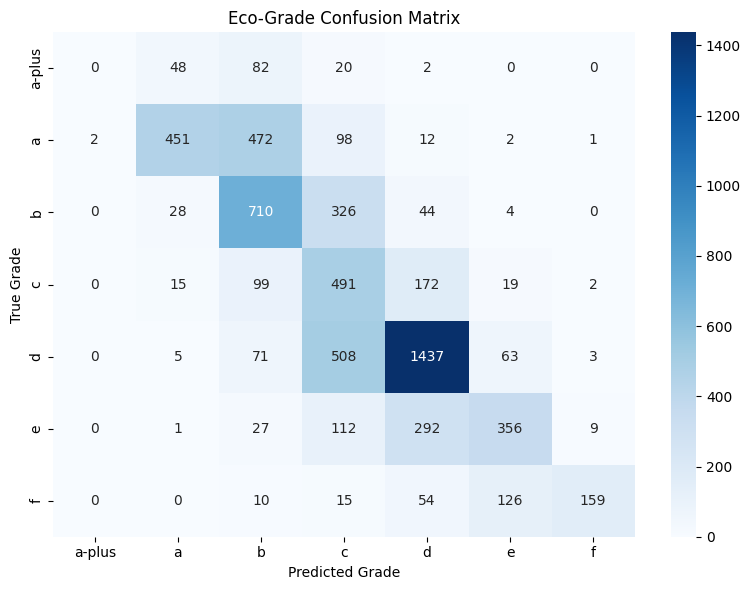

In [34]:
# ── 6a. EVALUATE ───────────────────────────────────────────────────────────────
 
y_pred_raw = model.predict(X_test_tfidf)
y_pred = np.clip(np.round(y_pred_raw), 0, len(GRADE_ORDER) - 1).astype(int)
 
grade_labels = GRADE_ORDER
 
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=grade_labels))
 
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (ordinal): {mae:.3f}")
print("(MAE of 0 = perfect, 1 = off by one grade on average)")
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=grade_labels, yticklabels=grade_labels
)
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")
plt.title("Eco-Grade Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [15]:
# Check how many a-plus predictions I'm actually getting
import collections
print(collections.Counter(y_pred))

Counter({4: 2017, 3: 1610, 2: 1427, 5: 583, 1: 548, 6: 163})


<b>Reflection on using XGBoost Regressor</b> XGBoost is not predicting A-plus at all. The regression approach assigns a continuous score and rounds it to the nearest integer. Because a-plus is class 0 - the very bottom of the scale - the model would need to predict a value below 0.5 to ever round down to it. Given that a-plus is rare and the regression is pulling predictions toward the middle of the distribution, it never gets close enough to 0.5 to round there. So we need a different model that is more likely to capture this class.

B. <b>XGBoost Classifier</b> is tried next because it sidesteps the specific mechanical problem present with XGBoost Regressor, because it doesn't round - it directly outputs a class probability for each of the 7 grades and picks the highest one. So 'A-plus' gets a fair shot at being predicted regardless of where it sits on the scale.

Fisrt experiment with minimum as 0 and max as 5000.

In [35]:
# ── 5b. XGBOOST CLASSIFIER MODEL ──────────────────────────────────────────────────
# Multiclass classifier — predicts probability for each grade independently

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(GRADE_ORDER),
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=50
)

[0]	validation_0-mlogloss:1.75321
[50]	validation_0-mlogloss:1.48834
[100]	validation_0-mlogloss:1.43677
[150]	validation_0-mlogloss:1.42554
[200]	validation_0-mlogloss:1.41972
[250]	validation_0-mlogloss:1.41500
[300]	validation_0-mlogloss:1.41190
[350]	validation_0-mlogloss:1.41018
[400]	validation_0-mlogloss:1.40865
[450]	validation_0-mlogloss:1.40791
[482]	validation_0-mlogloss:1.40731


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_class=7, ...)


── Classification Report ──
              precision    recall  f1-score   support

      a-plus       0.21      0.05      0.08       152
           a       0.71      0.77      0.74      1038
           b       0.70      0.77      0.73      1112
           c       0.64      0.56      0.60       798
           d       0.84      0.79      0.81      2087
           e       0.66      0.76      0.71       797
           f       0.80      0.83      0.81       364

    accuracy                           0.74      6348
   macro avg       0.65      0.65      0.64      6348
weighted avg       0.73      0.74      0.73      6348

Mean Absolute Error (ordinal): 0.409
(MAE of 0 = perfect, 1 = off by one grade on average)


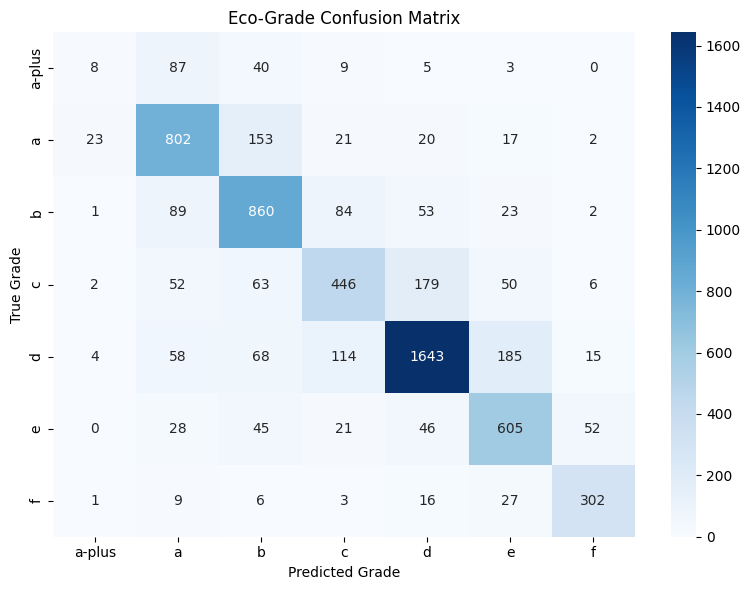

In [36]:
# ── 6b. EVALUATE ───────────────────────────────────────────────────────────────
 
y_pred_raw = model.predict(X_test_tfidf)
y_pred = np.clip(np.round(y_pred_raw), 0, len(GRADE_ORDER) - 1).astype(int)
 
grade_labels = GRADE_ORDER
 
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=grade_labels))
 
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (ordinal): {mae:.3f}")
print("(MAE of 0 = perfect, 1 = off by one grade on average)")
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=grade_labels, yticklabels=grade_labels
)
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")
plt.title("Eco-Grade Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [17]:
y_pred = model.predict(X_test_tfidf)

C. XGBClassifier, with a higher minimum of 762 and max of 5000

In [30]:
# ── 5c. XGBOOST CLASSIFIER MODEL ──────────────────────────────────────────────────
# Multiclass classifier — predicts probability for each grade independently

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(GRADE_ORDER),
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_test_tfidf, y_test)],
    verbose=50
)

[0]	validation_0-mlogloss:1.75202
[50]	validation_0-mlogloss:1.47975
[100]	validation_0-mlogloss:1.43136
[150]	validation_0-mlogloss:1.41925
[200]	validation_0-mlogloss:1.41309
[250]	validation_0-mlogloss:1.40845
[300]	validation_0-mlogloss:1.40544
[350]	validation_0-mlogloss:1.40308
[400]	validation_0-mlogloss:1.40189
[450]	validation_0-mlogloss:1.40099
[499]	validation_0-mlogloss:1.40000


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_class=7, ...)


── Classification Report ──
              precision    recall  f1-score   support

      a-plus       0.26      0.07      0.11       152
           a       0.71      0.77      0.74      1038
           b       0.70      0.77      0.73      1112
           c       0.63      0.56      0.59       798
           d       0.84      0.78      0.81      2087
           e       0.67      0.77      0.72       797
           f       0.80      0.84      0.82       364

    accuracy                           0.73      6348
   macro avg       0.66      0.65      0.65      6348
weighted avg       0.73      0.73      0.73      6348

Mean Absolute Error (ordinal): 0.411
(MAE of 0 = perfect, 1 = off by one grade on average)


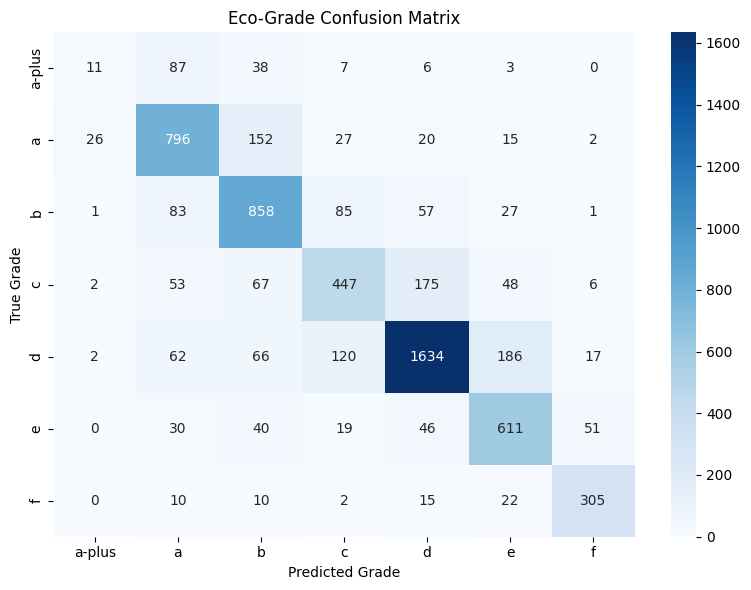

In [31]:
# ── 6c. EVALUATE ───────────────────────────────────────────────────────────────
 
y_pred_raw = model.predict(X_test_tfidf)
y_pred = np.clip(np.round(y_pred_raw), 0, len(GRADE_ORDER) - 1).astype(int)
 
grade_labels = GRADE_ORDER
 
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=grade_labels))
 
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (ordinal): {mae:.3f}")
print("(MAE of 0 = perfect, 1 = off by one grade on average)")
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=grade_labels, yticklabels=grade_labels
)
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")
plt.title("Eco-Grade Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [26]:
# ── 7. FEATURE IMPORTANCE ─────────────────────────────────────────────────────
# See which ingredients drive predictions most
 
feature_names = tfidf.get_feature_names_out()
importances = model.feature_importances_
top_n = 20
 
top_idx = np.argsort(importances)[-top_n:][::-1]
top_features = [(feature_names[i], importances[i]) for i in top_idx]
 
print(f"\n── Top {top_n} Most Predictive Ingredients ──")
for feat, score in top_features:
    print(f"  {feat:<30} {score:.4f}")


── Top 20 Most Predictive Ingredients ──
  long grain                     0.0133
  mustard spice                  0.0088
  olive oil                      0.0073
  honey added                    0.0061
  milk                           0.0059
  pulse                          0.0055
  vegetable fruit                0.0051
  tree nut                       0.0051
  vitamin b6                     0.0045
  milk dairy                     0.0043
  vegetable legume               0.0043
  soya bean                      0.0039
  b6                             0.0038
  seed condiment                 0.0036
  walnut                         0.0036
  rice rice                      0.0034
  palm oil                       0.0034
  grape juice                    0.0033
  cereal corn                    0.0033
  rice                           0.0030


# Final Results

In [40]:
summary = pd.DataFrame({
    "Model": [
        "XGBoost Regressor (ordinal encoding)",
        "XGBoost Classifier (multiclass)"
    ],
    "Accuracy": [0.57, 0.74],
    "Macro F1": [0.48, 0.65],
    "Weighted F1": [0.57, 0.73],
    "MAE": [0.545, 0.411],
    "Notes": [
        "Never predicted a-plus class",
        "Current model — a-plus still weak (F1 0.11)"
    ]
})

summary.style.set_caption("Model Comparison Summary")

,Model,Accuracy,Macro F1,Weighted F1,MAE,Notes
0,XGBoost Regressor (ordinal encoding),0.570000,0.480000,0.570000,0.545000,Never predicted a-plus class
1,XGBoost Classifier (multiclass),0.740000,0.650000,0.730000,0.411000,Current model — a-plus still weak (F1 0.11)
